### `dim_service` feature engineering & churn correlation

Engineer features **only** from `dim_service` warehouse columns, then measure **Pearson correlation** with **`churn`** (binary target; same row as in `fact_customer_churn`).

**Data:** `data/customer_churn_1M.csv`

**Outputs** (under `analysis/output/`):
- `service_churn_correlation_matrix.csv`
- `service_churn_correlation_with_churn.csv`
- `correlation_heatmap.png` (needs `matplotlib`, `seaborn`)

#### Paths and imports

In [10]:
from pathlib import Path

import numpy as np
import pandas as pd

_cwd = Path.cwd().resolve()
if (_cwd / "data" / "customer_churn_1M.csv").exists():
    ROOT = _cwd
elif (_cwd.parent / "data" / "customer_churn_1M.csv").exists():
    ROOT = _cwd.parent
else:
    ROOT = _cwd.parent

ANALYSIS_DIR = ROOT / "analysis"
OUTPUT_DIR = ANALYSIS_DIR / "output"
CSV_PATH = ROOT / "data" / "customer_churn_1M.csv"

print("ROOT:", ROOT)
print("CSV:", CSV_PATH, "exists:", CSV_PATH.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)

ROOT: /root/bt4301-group10/BT4301-Project-Group-10
CSV: /root/bt4301-group10/BT4301-Project-Group-10/data/customer_churn_1M.csv exists: True
OUTPUT_DIR: /root/bt4301-group10/BT4301-Project-Group-10/analysis/output


#### Column lists & helpers (`transform_dim_service`)

In [11]:
DIM_SERVICE_COLS = [
    "customer_id",
    "num_services",
    "has_phone_service",
    "has_internet_service",
    "has_online_security",
    "has_online_backup",
    "has_device_protection",
    "has_tech_support",
    "has_streaming_tv",
    "has_streaming_movies",
]

BINARY_FLAG_COLS = [c for c in DIM_SERVICE_COLS if c.startswith("has_")]


def coerce_binary(series: pd.Series) -> pd.Series:
    if series.dtype == object:
        lowered = series.astype(str).str.strip().str.lower()
        mapped = lowered.map(
            {
                "yes": 1,
                "y": 1,
                "true": 1,
                "1": 1,
                "no": 0,
                "n": 0,
                "false": 0,
                "0": 0,
                "": np.nan,
                "nan": np.nan,
            }
        )
        if mapped.notna().any():
            return pd.to_numeric(mapped, errors="coerce").fillna(0).astype(int)
    return pd.to_numeric(series, errors="coerce").fillna(0).astype(int)


def load_dim_service_with_churn(csv_path: Path) -> pd.DataFrame:
    usecols = DIM_SERVICE_COLS + ["churn"]
    df = pd.read_csv(csv_path, usecols=usecols, low_memory=False)
    for c in BINARY_FLAG_COLS:
        df[c] = coerce_binary(df[c])
    df["num_services"] = pd.to_numeric(df["num_services"], errors="coerce")
    median_ns = float(df["num_services"].median())
    df["num_services"] = df["num_services"].fillna(median_ns)
    df["churn"] = coerce_binary(df["churn"])
    return df.drop_duplicates(subset=["customer_id"], keep="first")

#### Feature engineering (`dim_service` only)

The following code defines `engineer_dim_service_features`. The **next markdown cell** documents each engineered column (including `high_service_count_flag` and `service_diversity_index` re-added for segmentation and add-on intensity).

In [12]:
def engineer_dim_service_features(df: pd.DataFrame) -> pd.DataFrame:
    """Engineered columns on top of raw dim_service (raw columns unchanged)."""
    out = df.copy()
    addon_cols = [
        "has_online_security",
        "has_online_backup",
        "has_device_protection",
        "has_tech_support",
        "has_streaming_tv",
        "has_streaming_movies",
    ]
    addon_count = out[addon_cols].sum(axis=1)

    out["num_services_x_internet"] = out["num_services"] * out["has_internet_service"]
    out["phone_without_internet"] = (
        (out["has_phone_service"] == 1) & (out["has_internet_service"] == 0)
    ).astype(int)
    out["high_service_count_flag"] = (out["num_services"] >= 4).astype(int)
    out["service_diversity_index"] = (
        addon_count / (out["num_services"].replace(0, np.nan))
    ).fillna(0.0)

    return out

**Engineered columns**

| Column | Explanation |
|--------|-------------|
| **`num_services_x_internet`** | `num_services × has_internet_service`. 0 without internet; with internet, equals total service count (explicit interaction for linear models). |
| **`phone_without_internet`** | 1 if phone line on and internet off (voice-only segment). |
| **`high_service_count_flag`** | 1 if `num_services ≥ 4`, else 0. Simple “large bundle” segment (threshold is a modeling choice). |
| **`service_diversity_index`** | (Sum of the six add-on flags) ÷ `num_services`. Rough share of the counted lines that are add-ons; 0 when `num_services` is 0. Uses the same six flags as in the ETL `dim_service` add-on list. |

#### Load data and build engineered frame

In [13]:
if not CSV_PATH.exists():
    raise FileNotFoundError(f"Place customer_churn_1M.csv under {ROOT / 'data'}")

base = load_dim_service_with_churn(CSV_PATH)
engineered = engineer_dim_service_features(base)
engineered.head()

,customer_id,num_services,has_phone_service,has_internet_service,has_online_security,has_online_backup,has_device_protection,has_tech_support,has_streaming_tv,has_streaming_movies,churn,num_services_x_internet,phone_without_internet,high_service_count_flag,service_diversity_index
0,CUST0000000001,1,1,1,0,0,1,1,1,1,0,1,0,0,4.000000
1,CUST0000000002,2,0,1,0,1,0,0,0,1,0,2,0,0,1.000000
2,CUST0000000003,4,1,1,0,0,1,1,1,0,0,4,0,1,0.750000
3,CUST0000000004,3,1,1,0,0,1,1,0,1,0,3,0,0,1.000000
4,CUST0000000005,3,0,1,0,0,0,0,0,1,0,3,0,0,0.333333


#### Correlation matrix vs `churn`

In [14]:
def correlation_vs_churn(df: pd.DataFrame, target: str = "churn"):
    exclude = {"customer_id", target, "row_fp"}
    feature_cols = [c for c in df.columns if c not in exclude and df[c].dtype != object]
    sub = df[feature_cols + [target]].dropna()
    corr = sub.corr(numeric_only=True)
    churn_corr = corr[target].drop(labels=[target], errors="ignore")
    churn_sorted = churn_corr.reindex(churn_corr.abs().sort_values(ascending=False).index)
    return corr, churn_sorted.to_frame("correlation_with_churn")


corr, vs_churn = correlation_vs_churn(engineered, target="churn")
pd.set_option("display.max_rows", 30)
vs_churn

,correlation_with_churn
has_tech_support,-0.045477
has_online_security,-0.034106
num_services_x_internet,-0.033955
num_services,-0.033378
high_service_count_flag,-0.027339
has_internet_service,-0.015261
phone_without_internet,0.011443
has_online_backup,-0.004919
has_device_protection,-0.004908
has_phone_service,-0.002274


#### Save CSVs and heatmap

In [15]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
corr.to_csv(OUTPUT_DIR / "service_churn_correlation_matrix.csv")
vs_churn.to_csv(OUTPUT_DIR / "service_churn_correlation_with_churn.csv")
print("Saved:", OUTPUT_DIR / "service_churn_correlation_matrix.csv")
print("Saved:", OUTPUT_DIR / "service_churn_correlation_with_churn.csv")

Saved: /root/bt4301-group10/BT4301-Project-Group-10/analysis/output/service_churn_correlation_matrix.csv
Saved: /root/bt4301-group10/BT4301-Project-Group-10/analysis/output/service_churn_correlation_with_churn.csv


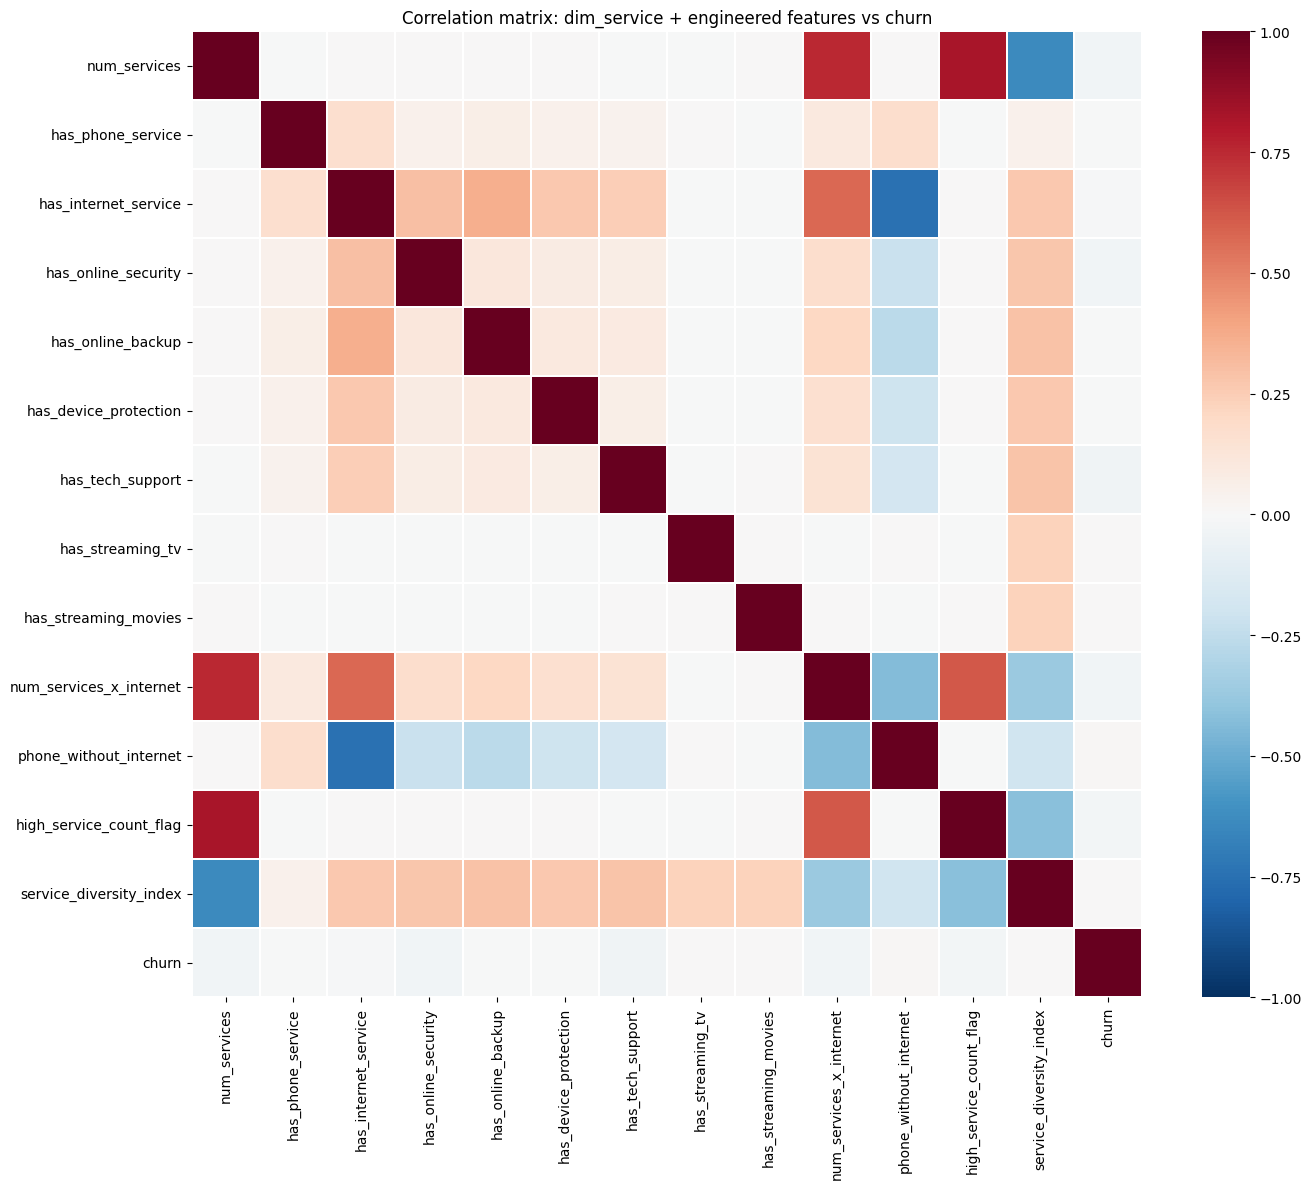

Saved: /root/bt4301-group10/BT4301-Project-Group-10/analysis/output/correlation_heatmap.png


In [16]:
try:
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(14, 12))
    sns.heatmap(
        corr,
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        square=False,
        linewidths=0.2,
    )
    plt.title("Correlation matrix: dim_service + engineered features vs churn")
    plt.tight_layout()
    heatmap_path = OUTPUT_DIR / "correlation_heatmap.png"
    plt.savefig(heatmap_path, dpi=150)
    plt.show()
    print("Saved:", heatmap_path)
except ImportError:
    print("Install matplotlib and seaborn for heatmap: pip install matplotlib seaborn")